## for the predicted..

# GHANA COVID-19 SEIR MODEL

**Model:** Standard SEIR (Susceptible -> Exposed -> Infectious -> Recovered)  
**Country:** Ghana  
**Period:** March 12, 2020 – March 31, 2021 (first wave)  
**Data:** Our World in Data (OWID) - `owid-covid-data.csv`  
**Download:** [https://github.com/owid/covid-19-data/tree/master/public/data](https://github.com/owid/covid-19-data/tree/master/public/data)

---

## SEIR Differential Equations

$$
\begin{align}
\frac{dS}{dt} &= -\frac{\beta S I}{N} && \text{(Susceptibles leaving due to infection)} \\
\frac{dE}{dt} &= \frac{\beta S I}{N} - \sigma E && \text{(Exposed: gain from S, drain to I)} \\
\frac{dI}{dt} &= \sigma E - \gamma I && \text{(Infectious: gain from E, drain to R)} \\
\frac{dR}{dt} &= \gamma I && \text{(Recovered: gain from I)}
\end{align}
$$

---

## Parameters

| Symbol | Meaning | Description |
|--------|---------|-------------|
| **β** (beta) | Transmission rate | Contacts × probability of transmission per day |
| **σ** (sigma) | Incubation rate | 1 / incubation period in days |
| **γ** (gamma) | Recovery rate | 1 / infectious period in days |
| **N** | Total population | Constant: \( S + E + I + R = N \) |
| **R₀** | Basic reproduction number | \( R_0 = beta / gamma) |

---

## References

- Frempong et al. (2021), *PLOS ONE* - Ghana R₀ estimate of 3.21  
- Incubation period: 5.2 days (Li et al., *NEJM* 2020)  
- Infectious period: 15 days (CDC / Frempong et al.)

## Importing Libraaries

In [ ]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from datetime import date, timedelta
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Plot styling 
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})
plt.style.use('seaborn-v0_8-whitegrid')

## MODEL PARAMETERS

In [ ]:
# These are the values you can modify to explore different scenarios.. all rates are per day

# Epidemiological parameters (literature-based)
sigma = 1 / 5.2                                   # σ: Rate from exposed to infectious  (incubation period = 5.2 days)
gamma = 1 / 15.0                                  # γ: Rate from infectious to recovered (infectious period = 15 days)

# Ghana population
N = 33_475_870.0                                 # N: Total population (constant with no births/deaths)

# Rate of transmission from literature
# R₀ = β / γ  -  so β = R₀ × γ
# Frempong et al. (PLOS ONE 2021) estimated R₀ = 3.21 for Ghana's first wave
beta_literature = 0.214
R0_literature = beta_literature / gamma

# Simulation period 
start_date = date(2020, 3, 12)                   # Ghana's first confirmed case
end_date   = date(2021, 3, 31)                   # End of first wave window
n_days     = (end_date - start_date).days


# Initial conditions for the THEORETICAL model
# On day 0 (March 12, 2020): 2 confirmed cases, ~150 undetected exposures

I0_theory = 50                                    # Initial infectious (seed)
E0_theory = 150                                   # Initial exposed (undetected; assumed ~3× I₀)
R0_init   = 0                                     # No recoveries yet
S0_theory = N - E0_theory - I0_theory - R0_init   # Everyone else susceptible

In [ ]:
# Initial conditions for the THEORETICAL model
# On day 0 (March 12, 2020): 2 confirmed cases, ~150 undetected exposures

I0_theory = 50                                    # Initial infectious (seed)
E0_theory = 150                                   # Initial exposed (undetected; assumed ~3× I₀)
R0_init   = 0                                     # No recoveries yet
S0_theory = N - E0_theory - I0_theory - R0_init   # Everyone else susceptible

## THE SEIR ODE FUNCTION

This encodes the four differential equations listed at the top and scipy's solve_ivp calls this function repeatedly to integrate over time.

In [ ]:
def seir_ode(t, y, beta):
    """
    SEIR system of ordinary differential equations.

    Parameters
    ----------
    t    : float  - current time (days); required by solve_ivp but not used explicitly
    y    : array  - [S, E, I, R] current compartment values
    beta : float  - transmission rate (fitted or literature-based)

    Returns
    -------
    [dS/dt, dE/dt, dI/dt, dR/dt]
    """
    S, E, I, R = y

    # Force of infection: rate at which susceptibles encounter infectious individuals
    # Dividing by N gives mass-action incidence (standard for a closed population)
    force_of_infection = beta * S * I / N

    dS_dt = -force_of_infection                    # S decreases as people get exposed
    dE_dt =  force_of_infection - sigma * E        # E gains from S, loses to I
    dI_dt =  sigma * E - gamma * I                 # I gains from E, loses to R
    dR_dt =  gamma * I                             # R gains from I

    return [dS_dt, dE_dt, dI_dt, dR_dt]

In [ ]:
def run_seir(beta, t_array, initial_conditions):
    """
    Solve the SEIR ODE system over a time array.

    Parameters
    ----------
    beta               : float  - transmission rate
    t_array            : array  - time points in days (e.g. 0, 1, 2, ..., 384)
    initial_conditions : list   - [S0, E0, I0, R0]

    Returns
    -------
    sol.y : array of shape (4, len(t_array)) - [S, E, I, R] at each time point
    """
    sol = solve_ivp(
        fun=seir_ode,
        t_span=[t_array[0], t_array[-1]],
        y0=initial_conditions,
        args=(beta,),
        method='LSODA',       # Stiff-aware solver - robust for epidemic models
        t_eval=t_array,
        rtol=1e-6,
        atol=1e-8
    )
    return sol.y    # Returns [S_array, E_array, I_array, R_array]

## RUNNING THE THEORETICAL MODEL 

This simulates the epidemic using literature parameters only. We can change the value for Beta above and re-run to explore scenarios.

In [15]:
# Time array: day 0 to day n_days (one point per day)
t_theory = np.arange(0, n_days + 1, dtype=float)

In [16]:
# Convert day numbers - actual calendar dates for x-axis labels
dates_theory = pd.to_datetime([start_date + timedelta(days=int(d)) for d in t_theory])

In [17]:
# Run the ODE solver with literature β
sol_theory = run_seir(
    beta=beta_literature,
    t_array=t_theory,
    initial_conditions=[S0_theory, E0_theory, I0_theory, R0_init]
)

In [18]:
# Unpack the four compartments from the solution
S_theory = sol_theory[0]   # Susceptible over time
E_theory = sol_theory[1]   # Exposed over time
I_theory = sol_theory[2]   # Infectious over time
R_theory = sol_theory[3]   # Recovered over time

In [21]:
sol_theory.shape

(4, 385)

In [ ]:
# Derived: theoretical daily new infections = σ × E  (rate of E-I transition)
new_infections_theory = sigma * E_theory

In [22]:
print("=" * 55)
print("  THEORETICAL MODEL (R₀ = {:.2f}, β = {:.4f})".format(R0_literature, beta_literature))
print("=" * 55)
print(f"  σ (incubation rate)  = {sigma:.4f}  [1 / 5.2 days]")
print(f"  γ (recovery rate)    = {gamma:.4f}  [1 / 15 days]")
print(f"  β (transmission)     = {beta_literature:.4f}  [R₀ × γ]")
print(f"  R₀                   = {R0_literature}")
print(f"  Peak Susceptible     = {S_theory.min():,.0f}  (minimum, i.e. most have left S)")
print(f"  Peak Exposed         = {E_theory.max():,.0f}  on day {E_theory.argmax()}")
print(f"  Peak Infectious      = {I_theory.max():,.0f}  on day {I_theory.argmax()}")
print(f"  Total Recovered      = {R_theory.max():,.0f}  by end of simulation")
print()

  THEORETICAL MODEL (R₀ = 3.21, β = 0.2140)
  σ (incubation rate)  = 0.1923  [1 / 5.2 days]
  γ (recovery rate)    = 0.0667  [1 / 15 days]
  β (transmission)     = 0.2140  [R₀ × γ]
  R₀                   = 3.21
  Peak Susceptible     = 1,457,824  (minimum, i.e. most have left S)
  Peak Exposed         = 3,098,421  on day 145
  Peak Infectious      = 7,373,522  on day 156
  Total Recovered      = 29,614,986  by end of simulation



## PLOTS

In [24]:
# fixes the labeling of the x and y axes for the plots
fmt  = mdates.DateFormatter('%b %Y')
xlim = (pd.Timestamp(start_date), pd.Timestamp(end_date))

def fmt_millions(x, pos):
    """Formatter: show population values as e.g. '5.0M' on y-axis"""
    return f'{x/1e6:.1f}M'

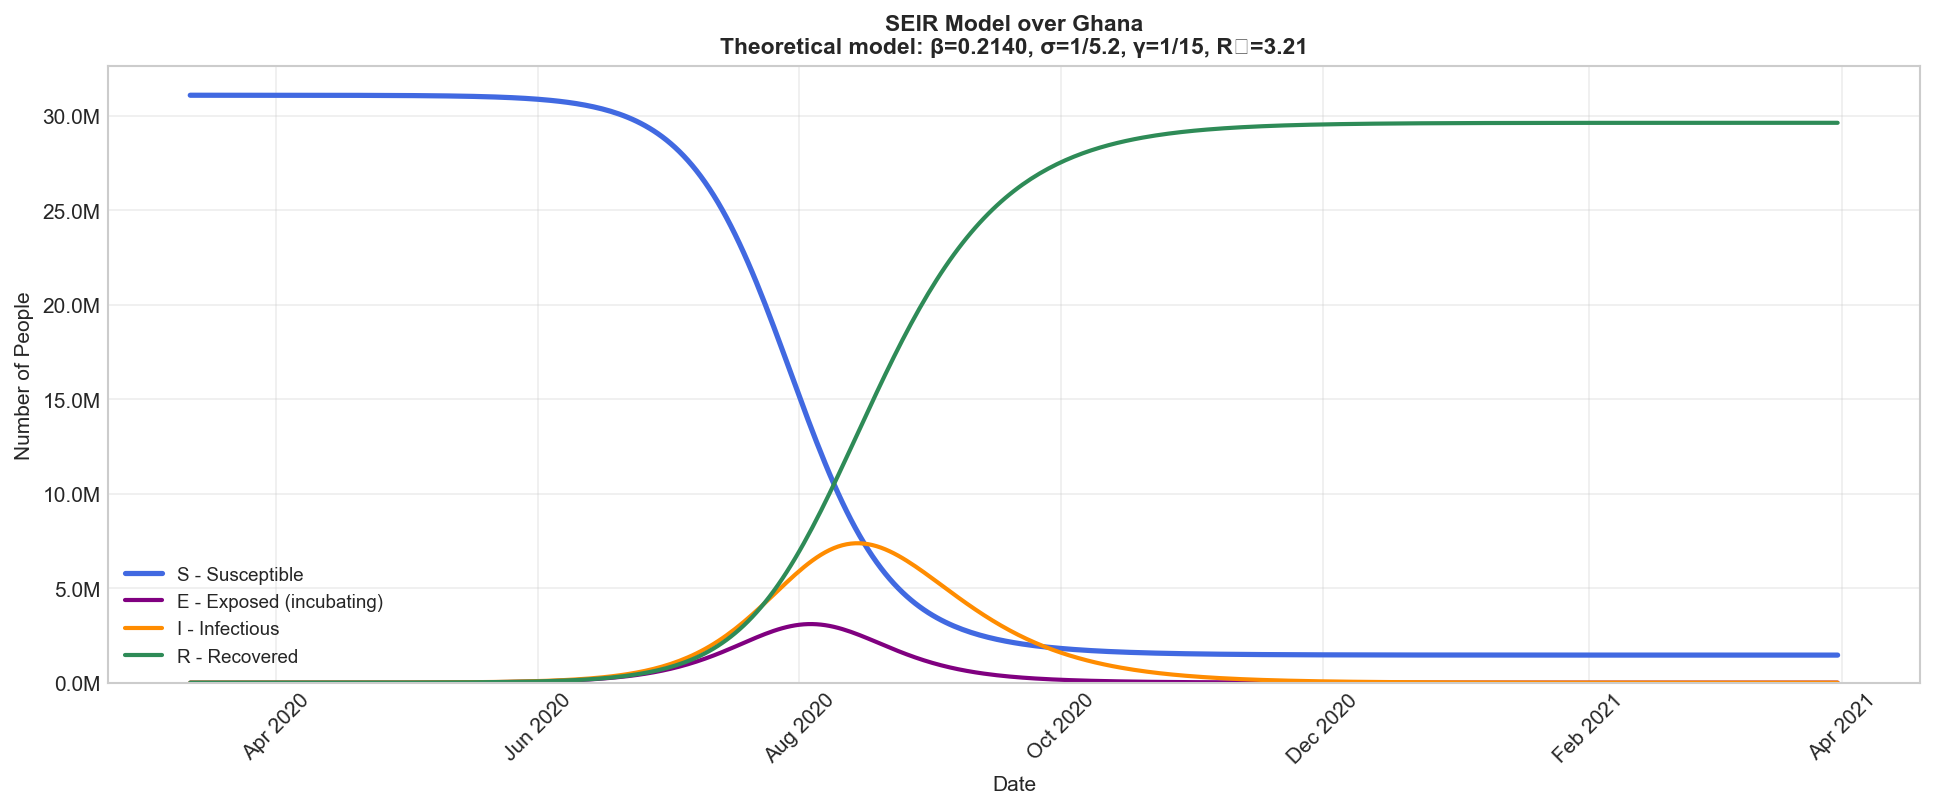

In [26]:
# Plotting the SEIR compartments over time
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(dates_theory, S_theory, color='royalblue',   lw=2.5, label='S - Susceptible') # plots how the susceptible population changes over time
ax.plot(dates_theory, E_theory, color='purple',       lw=2,   label='E - Exposed (incubating)') # plots how the exposed population changes over time
ax.plot(dates_theory, I_theory, color='darkorange',   lw=2,   label='I - Infectious') # plots how the infectious population changes over time
ax.plot(dates_theory, R_theory, color='seagreen',     lw=2,   label='R - Recovered') # plots how the recovered population changes over time

ax.set_title(
    'SEIR Model over Ghana\n'
    f'Theoretical model: β={beta_literature:.4f}, σ=1/5.2, γ=1/15, R₀={R0_literature}',
    fontsize=11, fontweight='bold'
)
ax.set_ylabel('Number of People')
ax.set_xlabel('Date')
ax.set_ylim(0, N * 1.05)                     # 0 to slightly above total population
ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt_millions))   # shows 0M, 5M, 10M…30M
ax.xaxis.set_major_formatter(fmt)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.35)

plt.tight_layout()
#plt.savefig('plot_B_compartments_population.png', dpi=150, bbox_inches='tight')
plt.show()
#print("Saved: plot_B_compartments_population.png")

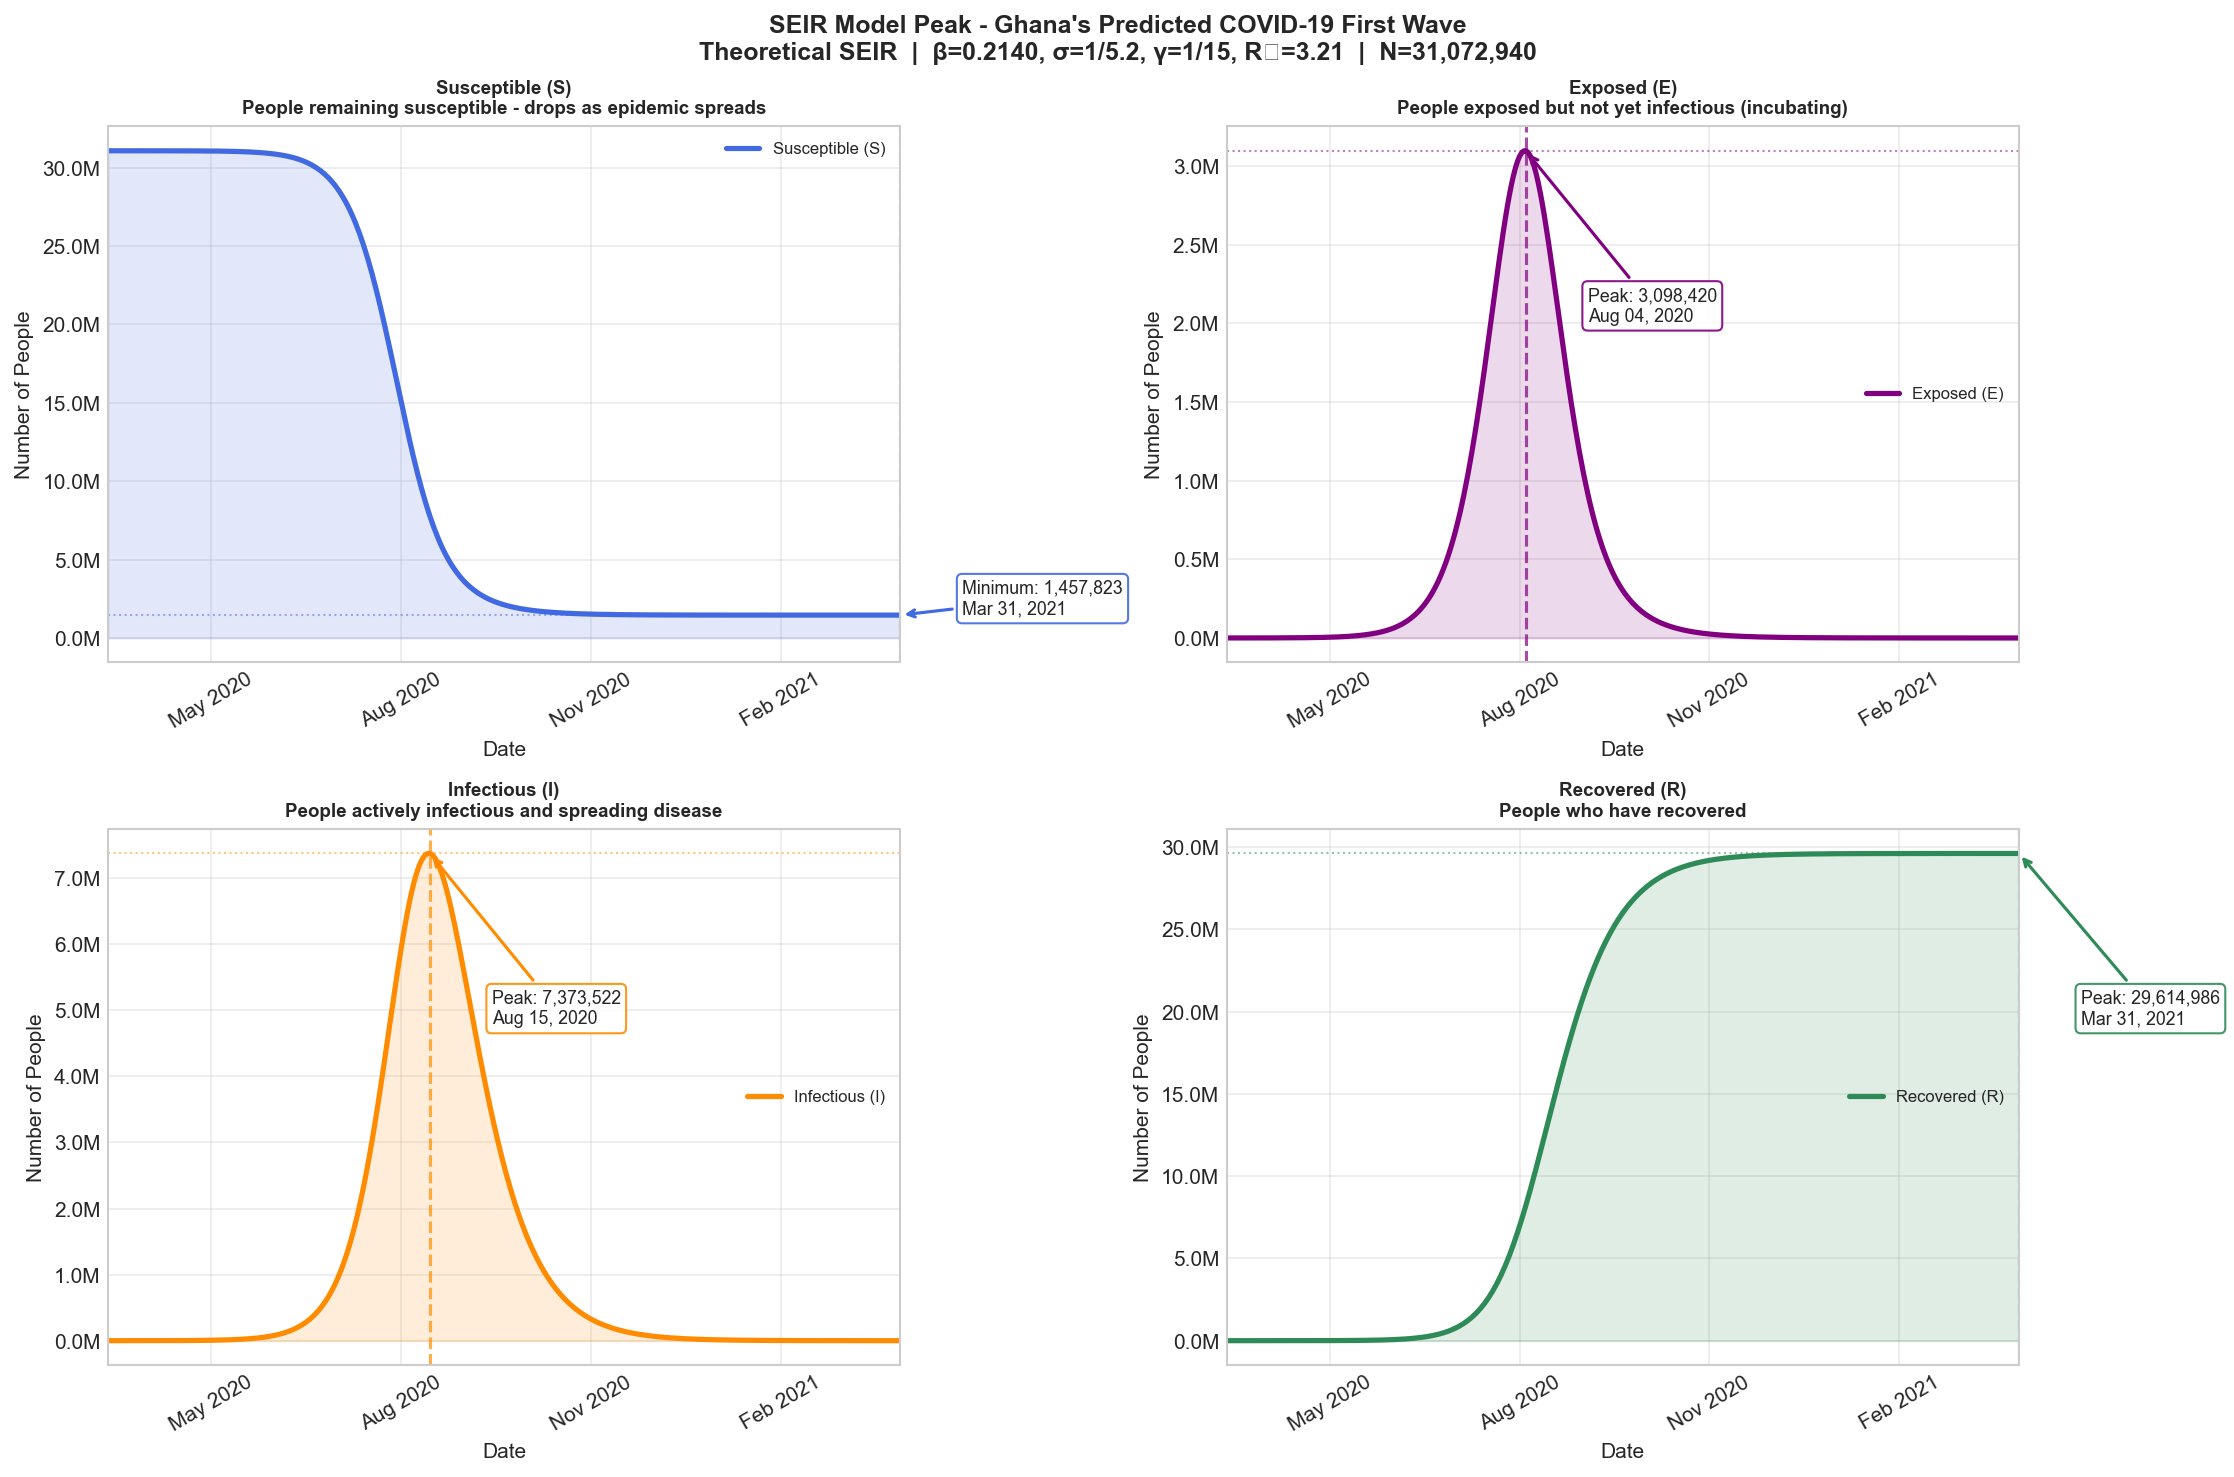

In [27]:
# Peak values for all four SEIR compartments (2×2 subplots)

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(
    'SEIR Model Peak - Ghana\'s Predicted COVID-19 First Wave\n'
    f'Theoretical SEIR  |  β={beta_literature:.4f}, σ=1/5.2, γ=1/15, R₀={R0_literature}  |  N={int(N):,}',
    fontsize=12, fontweight='bold'
)

compartments = [
    # (label,            values,    color,  peak = min/max,                                          units)
    ('Susceptible (S)', S_theory, 'royalblue',  'min',  'People remaining susceptible - drops as epidemic spreads'),
    ('Exposed (E)',     E_theory, 'purple',     'max',  'People exposed but not yet infectious (incubating)'),
    ('Infectious (I)',  I_theory, 'darkorange', 'max',  'People actively infectious and spreading disease'),
    ('Recovered (R)',   R_theory, 'seagreen',   'max',  'People who have recovered'),
]

for ax, (label, values, color, peak_type, subtitle) in zip(axs.flat, compartments):
    ax.plot(dates_theory, values, color=color, lw=2.5, label=label)
    ax.fill_between(dates_theory, values, alpha=0.15, color=color)

    # Find and annotate the peak
    if peak_type == 'max':
        peak_idx = values.argmax()
    else:
        peak_idx = values.argmin()   # Susceptible "peaks" at its minimum (most people infected)

    peak_val  = values[peak_idx]
    peak_date = dates_theory[peak_idx]

    ax.axvline(peak_date, color=color, lw=1.5, linestyle='--', alpha=0.7)
    ax.axhline(peak_val,  color=color, lw=1,   linestyle=':',  alpha=0.5)

    label_text = ('Minimum' if peak_type == 'min' else 'Peak')
    ax.annotate(
        f'{label_text}: {int(peak_val):,}\n{peak_date.strftime("%b %d, %Y")}',
        xy=(peak_date, peak_val),
        xytext=(peak_date + pd.Timedelta(days=30), peak_val * (0.65 if peak_type == 'max' else 1.05)),
        arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
        fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.9)
    )

    ax.set_title(f'{label}\n{subtitle}', fontsize=9, fontweight='bold')
    ax.set_ylabel('Number of People')
    ax.set_xlabel('Date')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt_millions))
    ax.xaxis.set_major_formatter(fmt)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.tick_params(axis='x', rotation=30)
    ax.set_xlim(*xlim)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
# plt.savefig('plot_E_peak_subplots.png', dpi=150, bbox_inches='tight')
plt.show()
# print("Saved: plot_E_peak_subplots.png")

In [31]:
print()
print("=" * 65)
print("  EPIDEMIC SUMMARY - THEORETICAL MODEL")
print("=" * 65)
print(f"  R₀  = {R0_literature}  (β={beta_literature:.4f}, γ={gamma:.4f}, σ={sigma:.4f})")
print(f"  N   = {int(N):,}")
print()

peak_S_day   = S_theory.argmin()
peak_S_date  = dates_theory[peak_S_day].strftime('%b %d, %Y')
peak_E_day   = E_theory.argmax()
peak_E_date  = dates_theory[peak_E_day].strftime('%b %d, %Y')
peak_I_day   = I_theory.argmax()
peak_I_date  = dates_theory[peak_I_day].strftime('%b %d, %Y')

print(f"  S minimum (herd immunity approx): {int(S_theory.min()):>12,}  on {peak_S_date}")
print(f"  E peak (most exposed at once):    {int(E_theory.max()):>12,}  on {peak_E_date}")
print(f"  I peak (most infectious at once): {int(I_theory.max()):>12,}  on {peak_I_date}")
print(f"  R final (total ever infected):    {int(R_theory.max()):>12,}")
print(f"  Attack rate:                      {R_theory.max()/N*100:.1f}% of population")
print()
print("  To explore scenarios, we can change beta_theoreticalat the top")
print("  and re-run. e.g. simulating reduced transmission post-intervention Ghana.")
print("=" * 65)


  EPIDEMIC SUMMARY - THEORETICAL MODEL
  R₀  = 3.21  (β=0.2140, γ=0.0667, σ=0.1923)
  N   = 31,072,940

  S minimum (herd immunity approx):    1,457,823  on Mar 31, 2021
  E peak (most exposed at once):       3,098,420  on Aug 04, 2020
  I peak (most infectious at once):    7,373,522  on Aug 15, 2020
  R final (total ever infected):      29,614,986
  Attack rate:                      95.3% of population

  To explore scenarios, we can change beta_theoreticalat the top
  and re-run. e.g. simulating reduced transmission post-intervention Ghana.


# for the actual..

# GHANA COVID-19 SEIR MODEL - DATA-DRIVEN R₀ CALCULATION

**Model:** Standard SEIR (Susceptible → Exposed → Infectious → Recovered)  
**Country:** Ghana  
**Period:** March 12, 2020 – March 31, 2021 (first wave)  
**Data:** Our World in Data (OWID) - `owid-covid-data.csv`  
**Download:** [https://github.com/owid/covid-19-data/tree/master/public/data](https://github.com/owid/covid-19-data/tree/master/public/data)

---

## How R₀ Is Calculated

We do **not** assume R₀. Instead:

1. We fix **σ** and **γ** from well-established biological literature  
   (incubation period and infectious period are measured from patients,  
   not from case counts, so they are reliable fixed values).

2. We fit **β** (the only free parameter) to Ghana’s real daily case data  
   by minimizing the squared error between model output and observations.

3. Once β is found from the data:

   $$
   R_0 = \frac{\beta}{\gamma}
   $$

   This R₀ is entirely **data-derived** - it reflects what actually happened  
   in Ghana, not a textbook assumption.

---

## SEIR Differential Equations

$$
\begin{align}
\frac{dS}{dt} &= -\frac{\beta \cdot S \cdot I}{N} && \text{S decreases as people get exposed} \\
\frac{dE}{dt} &= \frac{\beta \cdot S \cdot I}{N} - \sigma \cdot E && \text{E gains from S, drains to I at rate } \sigma \\
\frac{dI}{dt} &= \sigma \cdot E - \gamma \cdot I && \text{I gains from E, drains to R at rate } \gamma \\
\frac{dR}{dt} &= \gamma \cdot I && \text{R accumulates everyone leaving I}
\end{align}
$$

---

## Parameters

| Symbol | Meaning | Status |
|--------|---------|--------|
| **β** (beta) | Transmission rate per day | **Fitted** from data |
| **σ** (sigma) | 1 / incubation period | **Fixed:** 1/5.2 per day |
| **γ** (gamma) | 1 / infectious period | **Fixed:** 1/15 per day |
| **N** | Total population | **Fixed:** 33,475,870 |
| **R₀** | Basic reproduction number | **Calculated:** \( R_0 = beta / gamma) |

---

## References

- **Incubation 5.2 days:** Li et al. (*NEJM* 2020)  
- **Infectious 15 days:** Frempong et al. (*PLOS ONE* 2021) - Ghana-specific  
- **Ghana R₀ comparison:** Frempong et al. estimated 3.21 for the first wave

## Importing Libraries

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.integrate import solve_ivp
from scipy.optimize import minimize, differential_evolution
from datetime import date, timedelta
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})
plt.style.use('seaborn-v0_8-whitegrid')

## FIXED BIOLOGICAL PARAMETERS

In [34]:
sigma = 1 / 5.2
gamma = 1 / 15.0
N = 33_475_870.0 

start_date = date(2020, 3, 12)
end_date   = date(2021, 3, 31)
n_days     = (end_date - start_date).days

print("=" * 60)
print("  GHANA SEIR MODEL - DATA-DRIVEN R₀ ESTIMATION")
print("=" * 60)
print(f"  Fixed σ (incubation rate) = {sigma:.5f}  [1 / 5.2 days]")
print(f"  Fixed γ (recovery rate)   = {gamma:.5f}  [1 / 15 days]")
print(f"  Population N              = {int(N):,}")
print(f"  Study period              = {start_date} - {end_date}")
print()

  GHANA SEIR MODEL - DATA-DRIVEN R₀ ESTIMATION
  Fixed σ (incubation rate) = 0.19231  [1 / 5.2 days]
  Fixed γ (recovery rate)   = 0.06667  [1 / 15 days]
  Population N              = 33,475,870
  Study period              = 2020-03-12 - 2021-03-31



## THE SEIR ODE SYSTEM

In [35]:
def seir_ode(t, y, beta):
    S, E, I, R = y
    force_of_infection = beta * S * I / N
    dS_dt = -force_of_infection
    dE_dt =  force_of_infection - sigma * E
    dI_dt =  sigma * E - gamma * I
    dR_dt =  gamma * I
    return [dS_dt, dE_dt, dI_dt, dR_dt]


def run_seir(beta, t_array, y0):
    sol = solve_ivp(
        fun=seir_ode,
        t_span=[t_array[0], t_array[-1]],
        y0=y0,
        args=(beta,),
        method='LSODA',
        t_eval=t_array,
        rtol=1e-8,
        atol=1e-10
    )
    return sol.y

## LOADING AND PREPARATION OF GHANA CASE DATA

In [ ]:
print("Loading OWID data ...")
df    = pd.read_csv('owid-covid-data.csv')
ghana = df[df['iso_code'] == 'GHA'].copy()
ghana['date'] = pd.to_datetime(ghana['date'])
ghana = ghana.sort_values('date').reset_index(drop=True)

mask = (ghana['date'] >= pd.Timestamp(start_date)) & \
       (ghana['date'] <= pd.Timestamp(end_date))
data = ghana[mask].copy().reset_index(drop=True)

data['new_cases'] = pd.to_numeric(data['new_cases'], errors='coerce').fillna(0) #  Handle negative new_cases values (e.g., due to data corrections)
data['new_cases'] = data['new_cases'].clip(lower=0)                                  # THIS IS MAINLY TO ENSURE NO NEGATIVE VALUES IN NEW CASES
data['smoothed']  = data['new_cases'].rolling(7, center=True, min_periods=1).mean() # THIS IS A SMOOTHED VERSION OF THE NEW CASES DATA (7-DAY ROLLING AVERAGE)

t_data     = np.arange(len(data), dtype=float) # MAKES AN ARRAY OF DAY NUMBERS (0, 1, 2, ..., n_days) FOR THE DATA WINDOW
dates_data = pd.to_datetime([start_date + timedelta(days=int(d)) for d in t_data])

print(f"  Data loaded: {len(data)} days  ({data['date'].iloc[0].date()} "
      f"to {data['date'].iloc[-1].date()})")
print(f"  Total reported cases in window: {int(data['new_cases'].sum()):,}")
print()

Loading OWID data ...
  Data loaded: 385 days  (2020-03-12 to 2021-03-31)
  Total reported cases in window: 90,552



## INITIAL CONDITIONS

In [37]:
I0 = 5
E0 = 40
R0_init = 0
S0 = N - E0 - I0 - R0_init
y0 = [S0, E0, I0, R0_init]

## FITTING β TO ACTUAL CASE DATA FOR R₀ CALCULATION

In [ ]:
# The optimizer calls this function over and over, each time passing in a candidate β value to try.

def objective(beta_arr):
    beta_val = float(beta_arr[0])
    if beta_val <= 0:
        return 1e15
    try:
        sol = run_seir(beta_val, t_data, y0)   # It runs the full SEIR equations with that trial β and pulls out the Exposed compartment E(t) over time
        E_t = sol[1]
        model_new_cases = sigma * E_t           # This converts E(t) into the model's predicted daily new cases
                                                # The logic is that σ × E is the rate at which exposed people become infectious each day — which is exactly what a daily case report is trying to count.
        residuals = model_new_cases - data['smoothed'].values
        """
        Residuals variable subtracts the real smoothed Ghana data from the model's prediction at every single day, squares each difference (so positive and negative errors don't cancel), and sums them all up. 
        A small number means the model tracked reality closely. A large number means it did not. The optimizer's entire job is to find the β that makes this number as small as possible.
        """


        return np.sum(residuals ** 2)
    except Exception:
        return 1e15

In [39]:
print("Fitting β to Ghana case data (2-stage optimization) ...")

"""
differential_evolution is the broad sweep.. it does not start from one point and refine but it simultaneously explores many β values across the entire range 0.03 to 0.50, running objective() 
hundreds of times. This is important because the error landscape can have multiple valleys, and a simple local search would get stuck in whichever one it started near. This finds the right neighbourhood first.
"""

result_global = differential_evolution(
    objective,
    bounds=[(0.03, 0.50)],
    seed=42,
    maxiter=500,
    tol=1e-10,
    polish=True
)

"""
L-BFGS-B then takes the best β found by the global search and zooms in on it with high precision. Where differential_evolution was casting a wide net, this is fine-tuning to many decimal places.
"""

result_local = minimize(
    objective,
    x0=[result_global.x[0]],
    bounds=[(0.03, 0.50)],
    method='L-BFGS-B',
    options={'ftol': 1e-14, 'gtol': 1e-10, 'maxiter': 2000}
)


# Whichever stage achieved the lower error score wins. That winning value becomes beta_fitted.
if result_local.fun < result_global.fun:
    beta_fitted = float(result_local.x[0])
    fit_source  = "local refinement"
else:
    beta_fitted = float(result_global.x[0])
    fit_source  = "global search"

"""
Once β is known, R₀ is just arithmetic. γ was fixed at 1/15 from the start, so this single line divides the data-derived β by the literature-fixed γ to produce the reproduction 
number. The CSV data determined this value entirely.. we can change the input data and you get a different β and therefore a different R₀.
"""

R0_calculated = beta_fitted / gamma

print(f"  Optimization source       : {fit_source}")
print()
print("=" * 60)
print("  DATA-DERIVED RESULTS")
print("=" * 60)
print(f"  Fitted β (transmission)   = {beta_fitted:.6f} per day")
print(f"  Fixed σ (incubation rate) = {sigma:.6f} per day  [1/5.2]")
print(f"  Fixed γ (recovery rate)   = {gamma:.6f} per day  [1/15]")
print()
print(f"  ┌─────────────────────────────────────────────┐")
print(f"  │  R₀  =  β / γ  =  {beta_fitted:.6f} / {gamma:.6f}   │")
print(f"  │  R₀  =  {R0_calculated:.4f}                            │")
print(f"  └─────────────────────────────────────────────┘")
print()
print(f"  Interpretation: each infectious person in Ghana")
print(f"  infected approximately {R0_calculated:.2f} others on average")
print(f"  during the first wave (pre-intervention baseline).")
print()
print(f"  [Literature reference for comparison: Frempong et al.")
print(f"   (PLOS ONE 2021) estimated R₀ = 3.21 for Ghana's Wave 1]")
print()

Fitting β to Ghana case data (2-stage optimization) ...
  Optimization source       : global search

  DATA-DERIVED RESULTS
  Fitted β (transmission)   = 0.086831 per day
  Fixed σ (incubation rate) = 0.192308 per day  [1/5.2]
  Fixed γ (recovery rate)   = 0.066667 per day  [1/15]

  ┌─────────────────────────────────────────────┐
  │  R₀  =  β / γ  =  0.086831 / 0.066667   │
  │  R₀  =  1.3025                            │
  └─────────────────────────────────────────────┘

  Interpretation: each infectious person in Ghana
  infected approximately 1.30 others on average
  during the first wave (pre-intervention baseline).

  [Literature reference for comparison: Frempong et al.
   (PLOS ONE 2021) estimated R₀ = 3.21 for Ghana's Wave 1]



## RUN FITTED MODEL OVER FULL STUDY PERIOD

In [41]:
t_full     = np.arange(0, n_days + 1, dtype=float)
dates_full = pd.to_datetime([start_date + timedelta(days=int(d)) for d in t_full])

sol = run_seir(beta_fitted, t_full, y0)
S_fit = sol[0]
E_fit = sol[1]
I_fit = sol[2]
R_fit = sol[3]

new_cases_model = sigma * E_fit

sol_data_window       = run_seir(beta_fitted, t_data, y0)
new_cases_data_window = sigma * sol_data_window[1]

ss_res = np.sum((new_cases_data_window - data['smoothed'].values) ** 2)
ss_tot = np.sum((data['smoothed'].values - data['smoothed'].mean()) ** 2)
r2     = 1 - ss_res / ss_tot
rmse   = np.sqrt(np.mean((new_cases_data_window - data['smoothed'].values) ** 2))

# print(f"  Model fit quality:")
# print(f"    R²   = {r2:.4f}  (1.0 = perfect fit)")
# print(f"    RMSE = {rmse:.1f} cases/day")
# print()

peak_E_idx = E_fit.argmax()
peak_I_idx = I_fit.argmax()
min_S_idx  = S_fit.argmin()

print("=" * 60)
print("  EPIDEMIC PEAK SUMMARY (Data-Fitted Model)")
print("=" * 60)
print(f"  S minimum (fewest susceptible) : {int(S_fit.min()):>12,}  "
      f"on {dates_full[min_S_idx].strftime('%b %d, %Y')}")
print(f"  E peak (most exposed at once)  : {int(E_fit.max()):>12,}  "
      f"on {dates_full[peak_E_idx].strftime('%b %d, %Y')}")
print(f"  I peak (most infectious once)  : {int(I_fit.max()):>12,}  "
      f"on {dates_full[peak_I_idx].strftime('%b %d, %Y')}")
print(f"  R final (total ever infected)  : {int(R_fit.max()):>12,}")
print(f"  Attack rate (% of population)  : {R_fit.max()/N*100:.2f}%")
print("=" * 60)


  EPIDEMIC PEAK SUMMARY (Data-Fitted Model)
  S minimum (fewest susceptible) :   33,432,877  on Mar 31, 2021
  E peak (most exposed at once)  :        2,957  on Mar 31, 2021
  I peak (most infectious once)  :        7,039  on Mar 31, 2021
  R final (total ever infected)  :       32,995
  Attack rate (% of population)  : 0.10%


## PLOTS

In [42]:
fmt = mdates.DateFormatter('%b %Y')
xlim = (pd.Timestamp(start_date), pd.Timestamp(end_date))

def fmt_millions(x, pos):
    """Y-axis formatter: values ≥ 1 M shown as e.g. '5.0M', smaller as thousands."""
    if abs(x) >= 1e6:
        return f'{x/1e6:.1f}M'
    elif abs(x) >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

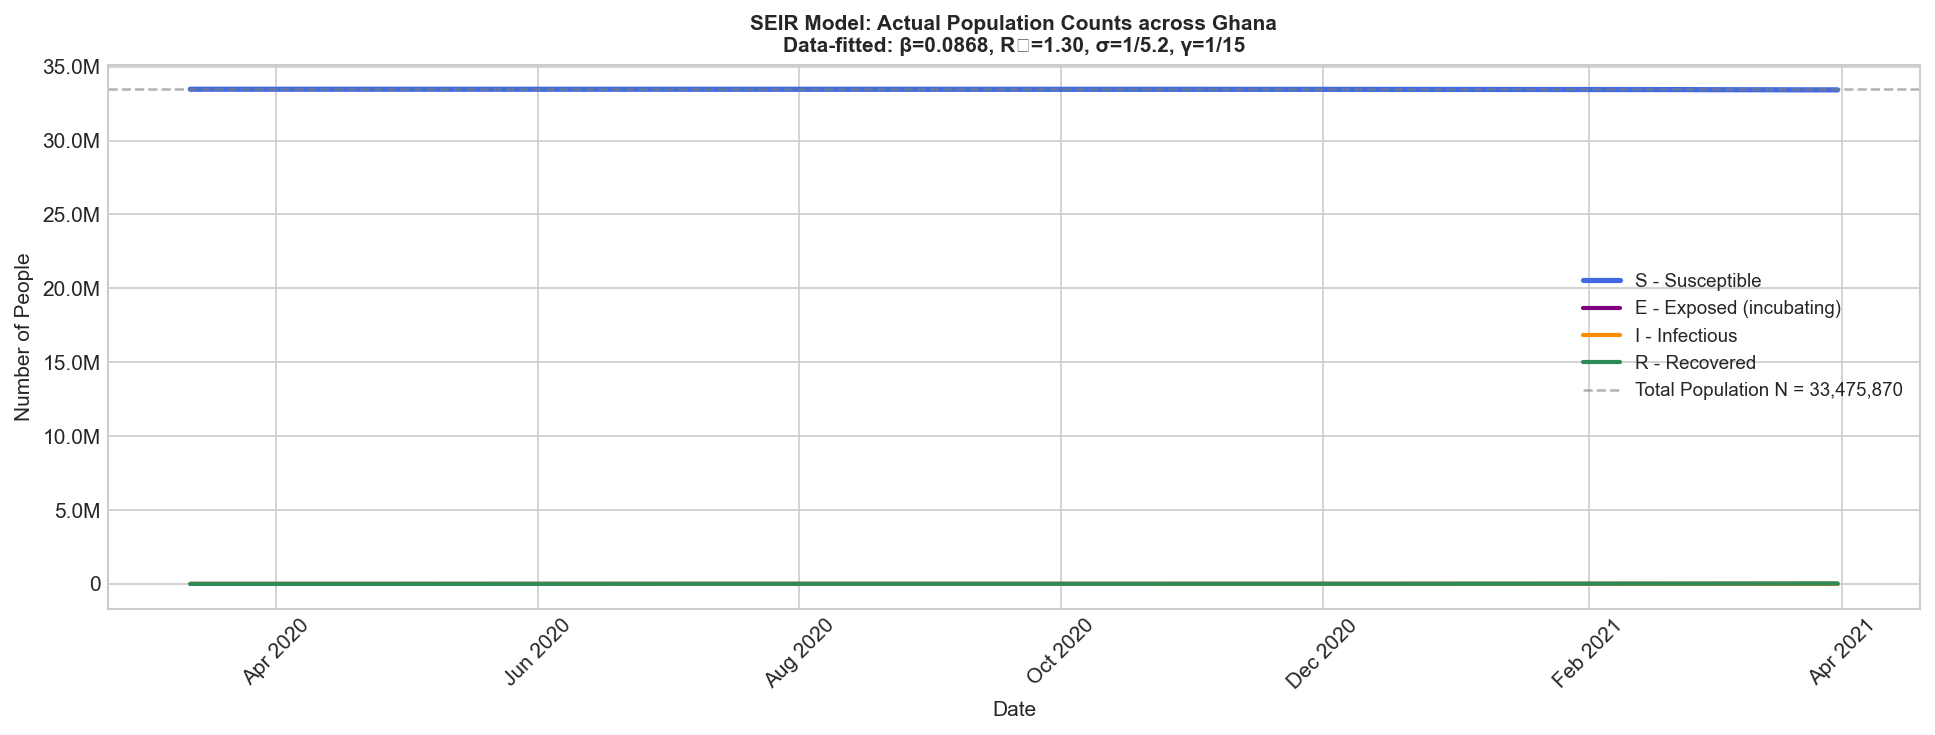

In [44]:
# SEIR Compartments in Actual Population Numbers

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(dates_full, S_fit, color='royalblue', lw=2.5, label='S - Susceptible')
ax.plot(dates_full, E_fit, color='purple',    lw=2,   label='E - Exposed (incubating)')
ax.plot(dates_full, I_fit, color='darkorange', lw=2,  label='I - Infectious')
ax.plot(dates_full, R_fit, color='seagreen',  lw=2,   label='R - Recovered')

# Reference line for total population - shows context without forcing y-axis to N
ax.axhline(N, color='gray', lw=1.2, linestyle='--', alpha=0.6,
           label=f'Total Population N = {int(N):,}')

ax.set_title(
    f'SEIR Model: Actual Population Counts across Ghana\n'
    f'Data-fitted: β={beta_fitted:.4f}, R₀={R0_calculated:.2f}, σ=1/5.2, γ=1/15',
    fontsize=10, fontweight='bold'
)
ax.set_ylabel('Number of People')
ax.set_xlabel('Date')
# Auto-scale: y-axis driven by the plotted data, not forced to N
ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt_millions))
ax.xaxis.set_major_formatter(fmt)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)

plt.tight_layout()
#plt.savefig('plot_B_population_compartments.png', dpi=150, bbox_inches='tight')
plt.show()
#print("Saved: plot_B_population_compartments.png")

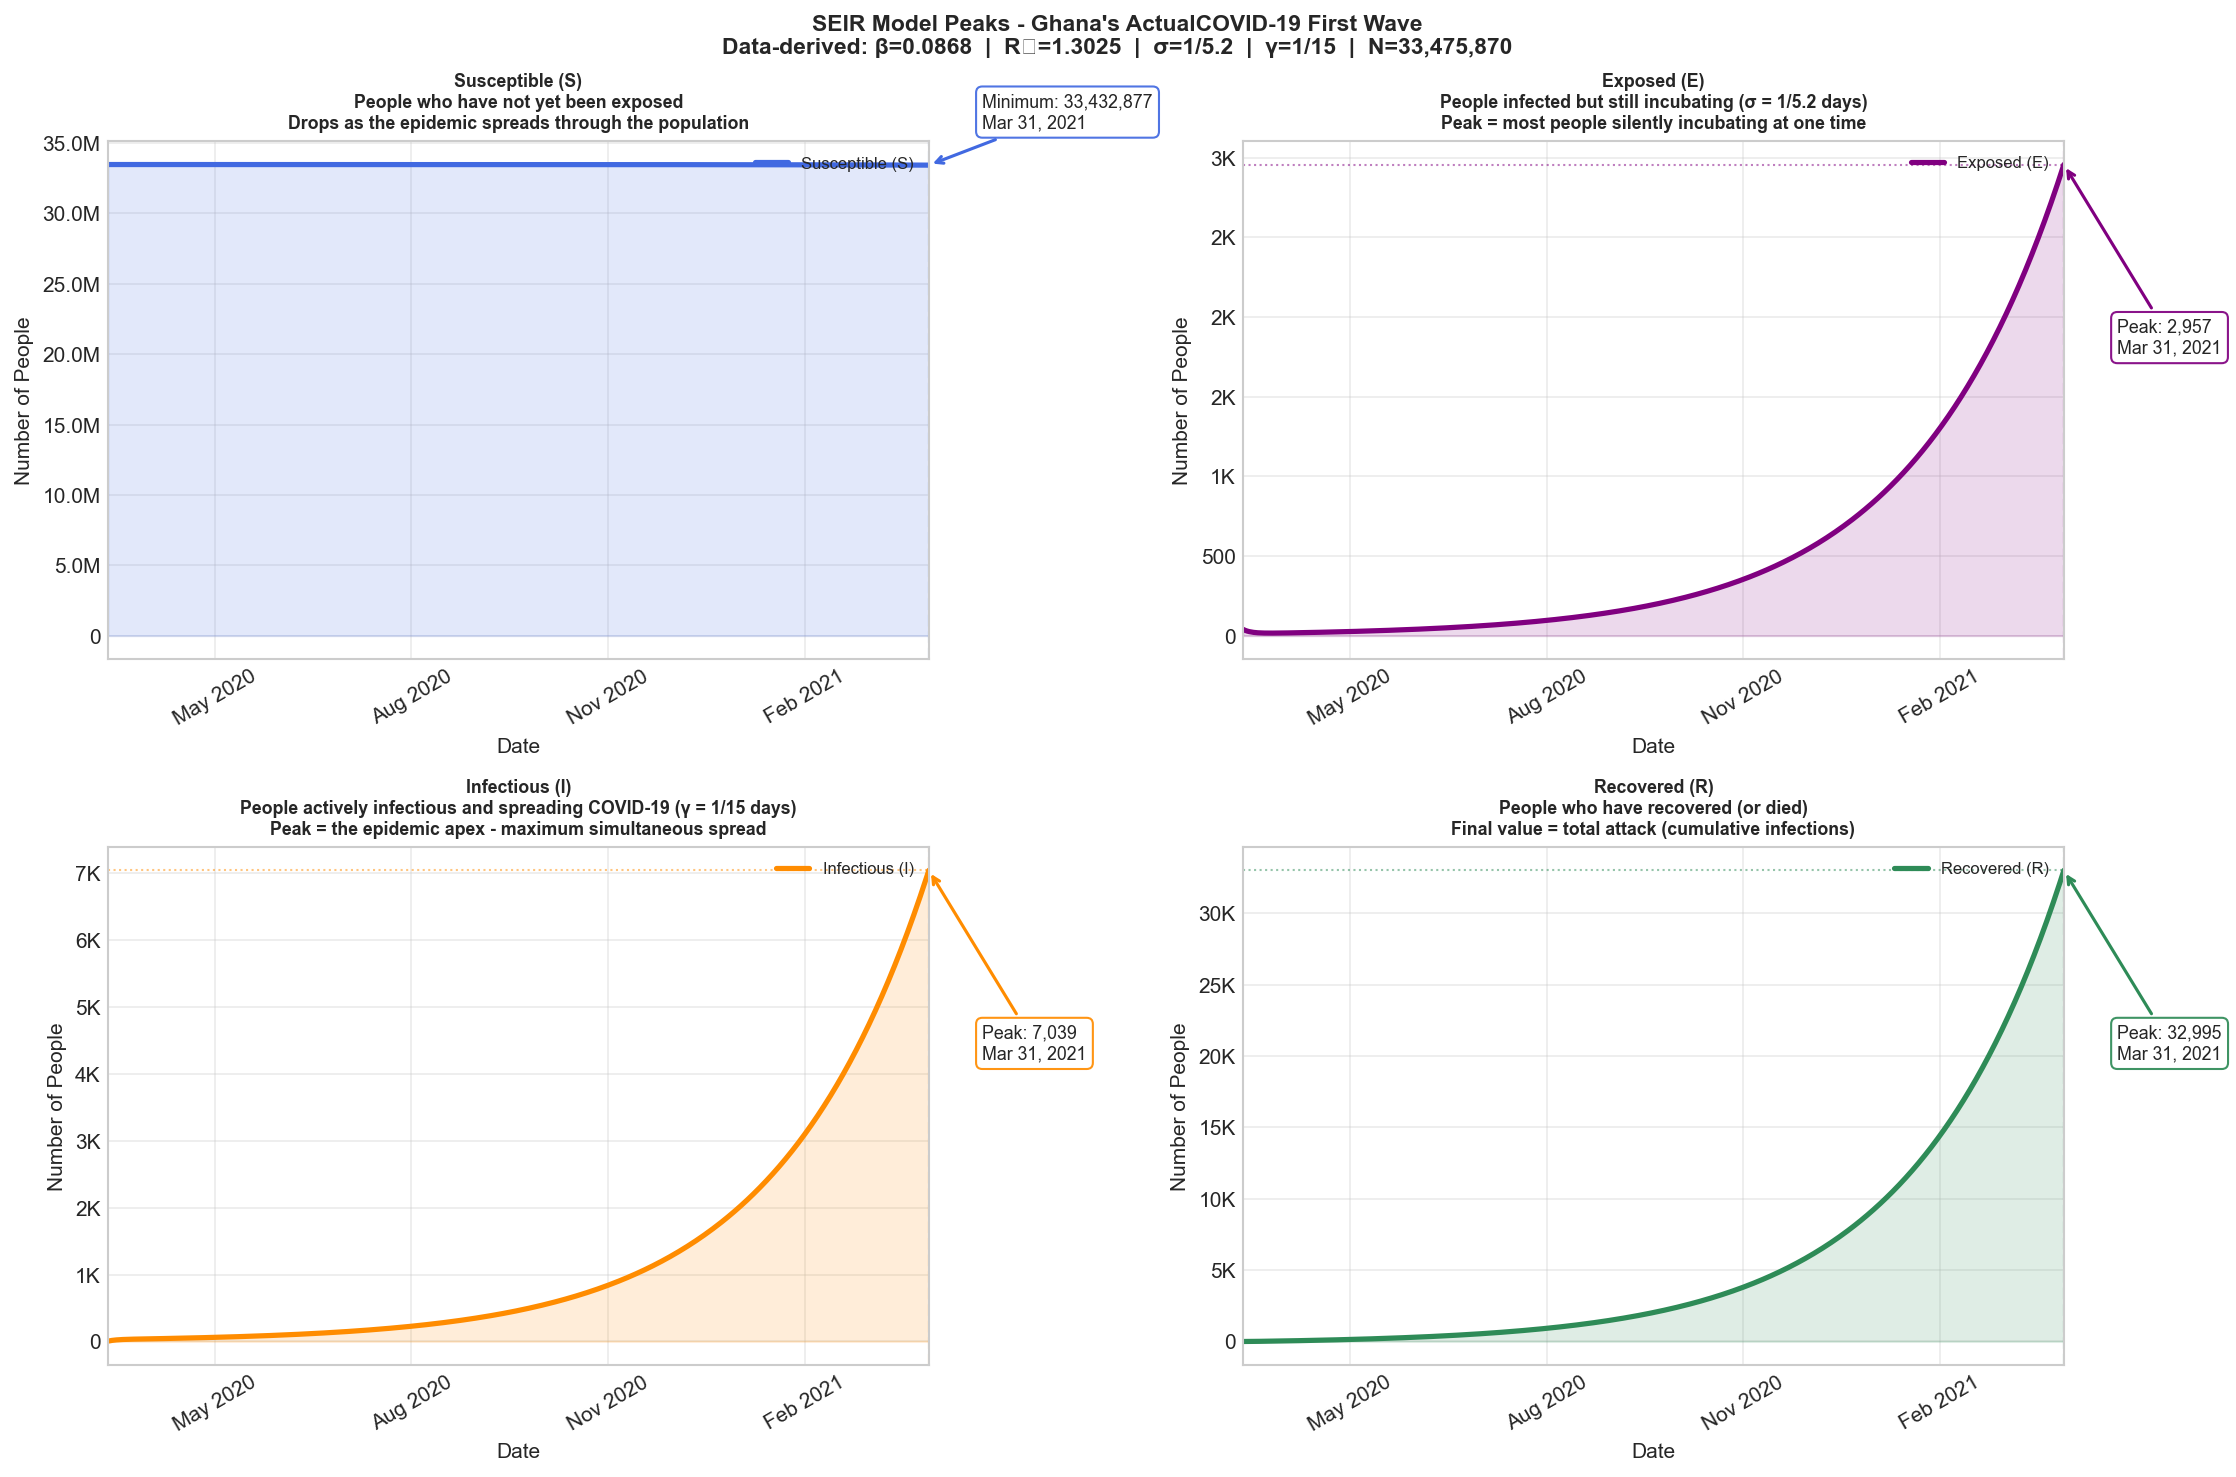

In [45]:
#  Peak Subplots for All Four SEIR Compartments

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(
    f"SEIR Model Peaks - Ghana's ActualCOVID-19 First Wave\n"
    f"Data-derived: β={beta_fitted:.4f}  |  R₀={R0_calculated:.4f}  |  "
    f"σ=1/5.2  |  γ=1/15  |  N={int(N):,}",
    fontsize=11, fontweight='bold'
)

compartments = [
    (
        'Susceptible (S)', S_fit, 'royalblue', 'min',
        'People who have not yet been exposed\n'
        'Drops as the epidemic spreads through the population'
    ),
    (
        'Exposed (E)', E_fit, 'purple', 'max',
        'People infected but still incubating (σ = 1/5.2 days)\n'
        'Peak = most people silently incubating at one time'
    ),
    (
        'Infectious (I)', I_fit, 'darkorange', 'max',
        'People actively infectious and spreading COVID-19 (γ = 1/15 days)\n'
        'Peak = the epidemic apex - maximum simultaneous spread'
    ),
    (
        'Recovered (R)', R_fit, 'seagreen', 'max',
        'People who have recovered (or died)\n'
        'Final value = total attack (cumulative infections)'
    ),
]

for ax, (label, values, color, peak_type, subtitle) in zip(axs.flat, compartments):

    ax.plot(dates_full, values, color=color, lw=2.5, label=label)
    ax.fill_between(dates_full, values, alpha=0.15, color=color)

    peak_idx  = values.argmax() if peak_type == 'max' else values.argmin()
    peak_val  = values[peak_idx]
    peak_date = dates_full[peak_idx]

    ax.axvline(peak_date, color=color, lw=1.5, linestyle='--', alpha=0.6)
    ax.axhline(peak_val,  color=color, lw=1.0, linestyle=':',  alpha=0.5)

    critical_label = 'Minimum' if peak_type == 'min' else 'Peak'
    annotation_y   = peak_val * 1.08 if peak_type == 'min' else peak_val * 0.60

    ax.annotate(
        f'{critical_label}: {int(peak_val):,}\n{peak_date.strftime("%b %d, %Y")}',
        xy=(peak_date, peak_val),
        xytext=(peak_date + pd.Timedelta(days=25), annotation_y),
        arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
        fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor=color, alpha=0.92)
    )

    ax.set_title(f'{label}\n{subtitle}', fontsize=8.5, fontweight='bold')
    ax.set_ylabel('Number of People')
    ax.set_xlabel('Date')
    # No set_ylim - each panel auto-scales to its own compartment's data range
    ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt_millions))
    ax.xaxis.set_major_formatter(fmt)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.tick_params(axis='x', rotation=30)
    ax.set_xlim(*xlim)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.4)

plt.tight_layout()
# plt.savefig('plot_E_peak_subplots.png', dpi=150, bbox_inches='tight')
plt.show()
# print("Saved: plot_E_peak_subplots.png")


In [47]:
print()
print("=" * 60)
print("  DATA-DERIVED SEIR MODEL (GHANA)")
print("=" * 60)
print(f"  Fitted β             = {beta_fitted:.6f} per day")
print(f"  Fixed  σ             = {sigma:.6f} per day  (1/5.2)")
print(f"  Fixed  γ             = {gamma:.6f} per day  (1/15)")
print(f"  Calculated R₀ = β/γ  = {R0_calculated:.4f}")
# print(f"  Model R²             = {r2:.4f}")
# print(f"  Model RMSE           = {rmse:.1f} cases/day")
print()
print(f"  Peak Exposed   : {int(E_fit.max()):>12,} people  "
      f"({dates_full[peak_E_idx].strftime('%b %d, %Y')})")
print(f"  Peak Infectious: {int(I_fit.max()):>12,} people  "
      f"({dates_full[peak_I_idx].strftime('%b %d, %Y')})")
print(f"  Total Infected : {int(R_fit.max()):>12,} people  "
      f"({R_fit.max()/N*100:.2f}% attack rate)")
print("=" * 60)


  DATA-DERIVED SEIR MODEL (GHANA)
  Fitted β             = 0.086831 per day
  Fixed  σ             = 0.192308 per day  (1/5.2)
  Fixed  γ             = 0.066667 per day  (1/15)
  Calculated R₀ = β/γ  = 1.3025

  Peak Exposed   :        2,957 people  (Mar 31, 2021)
  Peak Infectious:        7,039 people  (Mar 31, 2021)
  Total Infected :       32,995 people  (0.10% attack rate)
